# Advanced Model Analysis - Random Forest and XGBoost

This notebook extends the modelling analysis by implementing more flexible machine learning algorithms, **Random Forest** and **XGBoost**, to predict customer response to the monthly food basket subscription campaign. While logistic regression provides a useful baseline and interpretable benchmark, tree-based ensemble methods can capture non-linear relationships, complex feature interactions, and heterogeneous customer behaviour that linear models may miss.

The modelling strategy follows a structured evaluation framework:

1.	**A Random Forest Model** to capture non-linear patterns and interactions between customer characteristics while maintaining robustness through ensemble averaging.
2.	**An XGBoost Model**, a gradient boosting approach designed to iteratively correct prediction errors and produce highly accurate probability estimates.
3.	**Behavioural and Demographic Model Variants**, allowing us to assess whether campaign response is better explained by how customers behave or who the customers are.

Comparing these models allows us to evaluate improvements over the logistic regression baseline, assess the relative importance of behavioural versus demographic information, and identify the most effective modelling approach for targeting customers with the highest probability of responding to the campaign.


## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier


# Sklearn — preprocessing & splitting
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    RandomizedSearchCV, StratifiedKFold,
    learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.stats import randint

# Sklearn — models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Sklearn — evaluation
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance

In [2]:
# Data loading
df = pd.read_csv('../data/marketing_campaign_clean.csv')

# Data overview
print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nClass balance:")
print(df['Response'].value_counts(normalize=True).round(3))
df.columns


Dataset shape: 2236 rows × 30 columns

Class balance:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Income_missing', 'Customer_Tenure', 'Age',
       'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
       'Response'],
      dtype='object')

## 1. Feature Selection

Using the previously defined feature sets, three input matrices are created: `X_full`, `X_behav`, and `X_demo`, corresponding to the full, behavioural, and demographic feature configurations. Categorical variables are converted into dummy variables where necessary. The target variable y corresponds to the campaign response indicator.

In [3]:
# Create copy of the dataframe for modeling
df_model = df.copy()

# Drop columns that won't be used in the model
cols_to_drop = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Income_missing', 'Complain'
]
df_model = df_model.drop(columns=cols_to_drop)

# Target
target = 'Response'

# Full Model: all available features
numerical_features_full = [
    'Age', 'Income', 'Recency', 'Customer_Tenure',
    'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'Kidhome', 'Teenhome'
]
categorical_features_full = ['Education', 'Marital_Status']

# Behavioural Model: purchase & campaign engagement only
numerical_features_behav = [
    'Recency', 'Total_Spending', 'Total_Purchases',
    'Total_Accepted_Campaigns', 'NumDealsPurchases', 'NumWebVisitsMonth'
]
categorical_features_behav = []

# Demographic Model: customer profile only
numerical_features_demo = [
    'Age', 'Income', 'Customer_Tenure',
    'Kidhome', 'Teenhome'
]
categorical_features_demo = ['Education', 'Marital_Status']

print(f"Full model   : {len(numerical_features_full)} numerical + {len(categorical_features_full)} categorical")
print(f"Behavioural  : {len(numerical_features_behav)} numerical + {len(categorical_features_behav)} categorical")
print(f"Demographic  : {len(numerical_features_demo)} numerical + {len(categorical_features_demo)} categorical")


Full model   : 11 numerical + 2 categorical
Behavioural  : 6 numerical + 0 categorical
Demographic  : 5 numerical + 2 categorical


In [4]:
X_full  = pd.concat([df_model[numerical_features_full],
                     pd.get_dummies(df_model[categorical_features_full],  drop_first=True)], axis=1)

X_behav = df_model[numerical_features_behav].copy()

X_demo  = pd.concat([df_model[numerical_features_demo],
                     pd.get_dummies(df_model[categorical_features_demo],  drop_first=True)], axis=1)

y = df_model[target].copy()

print(f"\nX_full  shape : {X_full.shape}")
print(f"X_behav shape : {X_behav.shape}")
print(f"X_demo  shape : {X_demo.shape}")
print(f"y       shape : {y.shape}  | Positive rate: {y.mean():.1%}")



X_full  shape : (2236, 20)
X_behav shape : (2236, 6)
X_demo  shape : (2236, 14)
y       shape : (2236,)  | Positive rate: 14.9%


## 2. Train/Test Split

The dataset is split into training and test sets using an 80/20 split. Stratified sampling is applied to ensure that the proportion of positive responses remains similar in both subsets. This helps maintain the class distribution of the original dataset and provides a more reliable evaluation of model performance.

The same indices are used to create training and test splits for the full, behavioural, and demographic feature sets, ensuring that all models are evaluated on the exact same observations.

In [5]:
idx_train, idx_test = train_test_split(
    np.arange(len(y)),
    test_size=0.20,
    random_state=42,
    stratify=y          # ensures same ~15% positive rate in both splits
)

# Full model splits (primary)
X_full_train,  X_full_test  = X_full.iloc[idx_train],  X_full.iloc[idx_test]
# Behavioural model splits
X_behav_train, X_behav_test = X_behav.iloc[idx_train], X_behav.iloc[idx_test]
# Demographic model splits
X_demo_train,  X_demo_test  = X_demo.iloc[idx_train],  X_demo.iloc[idx_test]

y_train = y.iloc[idx_train]
y_test  = y.iloc[idx_test]

# Convenience aliases so the rest of the script works with the Full model
# by default — swap these to run the other feature sets
X_train, X_test = X_full_train, X_full_test

print(f"Train size : {len(y_train)} rows | Test size : {len(y_test)} rows")
print(f"Train positive rate: {y_train.mean():.1%}")
print(f"Test  positive rate: {y_test.mean():.1%}")

Train size : 1788 rows | Test size : 448 rows
Train positive rate: 14.9%
Test  positive rate: 15.0%


## 3. Full Model - Random Forest

The first advanced model is a Random Forest classifier trained on the full feature set, which includes both behavioural and demographic predictors. Random Forest is an ensemble method that combines multiple decision trees to capture non-linear relationships and interactions between variables.

Using the full set of features provides a comprehensive benchmark and allows us to evaluate how well the model performs when all available information about the customer is used.

### 3.1 Baseline Model before tuning

Before performing hyperparameter tuning, a baseline Random Forest model is trained using the default configuration. This provides a reference level of performance for comparison with the tuned model in section 3.3.

To address the class imbalance in the dataset, the parameter `class_weight='balanced'` is applied so that the minority class (customers who responded to the campaign) receives greater weight during training.

In [6]:
rf_default = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_default.fit(X_train, y_train)

y_pred_default  = rf_default.predict(X_test)
y_prob_default  = rf_default.predict_proba(X_test)[:, 1]

print(f"Default RF — ROC-AUC : {roc_auc_score(y_test, y_prob_default):.4f}")
print(f"Default RF — Recall  : {recall_score(y_test, y_pred_default):.4f}")
print(f"Default RF — F1      : {f1_score(y_test, y_pred_default):.4f}")

Default RF — ROC-AUC : 0.8636
Default RF — Recall  : 0.2836
Default RF — F1      : 0.3958


### 3.2 Out-of-Bag (OOB) Score Evaluation

Random Forest models use bootstrap sampling when building individual trees. Observations that are not included in a given bootstrap sample are called **out-of-bag (OOB) observations**.

These observations can be used as an internal validation set to estimate model performance during training. The OOB score therefore provides a quick indication of how well the model generalises without requiring an additional validation split.

In [7]:
rf_oob = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    oob_score=True,
    n_jobs=-1
)
rf_oob.fit(X_train, y_train)

print(f"OOB Score (accuracy proxy): {rf_oob.oob_score_:.4f}")
print("Note: OOB uses ~1/3 of data excluded from each bootstrap sample.")
print("It serves as a built-in cross-validation estimate.")

OOB Score (accuracy proxy): 0.8814
Note: OOB uses ~1/3 of data excluded from each bootstrap sample.
It serves as a built-in cross-validation estimate.


### 3.3 Hyperparameter tuning via RandomizedSearchCV

To improve model performance, we tune key Random Forest hyperparameters using **RandomizedSearchCV**. This method samples different combinations of parameters from predefined distributions and evaluates them using stratified **5-fold cross-validation**.

We use **ROC-AUC** as the optimisation metric, since the goal is to distinguish between customers who respond to the campaign and those who do not.

In [8]:
param_dist = {
    'n_estimators':      randint(100, 500),
    'max_depth':         [None, 5, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator  = RandomForestClassifier(
                     random_state=42,
                     class_weight='balanced',
                     n_jobs=1
                 ),
    param_distributions = param_dist,
    n_iter     = 5,
    cv         = cv_strategy,
    scoring    = 'roc_auc',
    random_state = 42,
    n_jobs     = 1,
    verbose    = 1
)

random_search.fit(X_train, y_train)

print(f"Best parameters : {random_search.best_params_}")
print(f"Best CV AUC     : {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 13, 'n_estimators': 413}
Best CV AUC     : 0.8866


### 3.4 Evaluate best model on test set

Our business problem is to rank customers by likelihood to respond for which we use the AUC as main metric but also report **precision, recall, f1** to show trade-offs.

ROC-AUC    : 0.8799   
Precision  : 0.6207
Recall     : 0.5373   
F1-Score   : 0.5760
Accuracy   : 0.8817  

Full classification report:
              precision    recall  f1-score   support

 No Response       0.92      0.94      0.93       381
    Response       0.62      0.54      0.58        67

    accuracy                           0.88       448
   macro avg       0.77      0.74      0.75       448
weighted avg       0.88      0.88      0.88       448



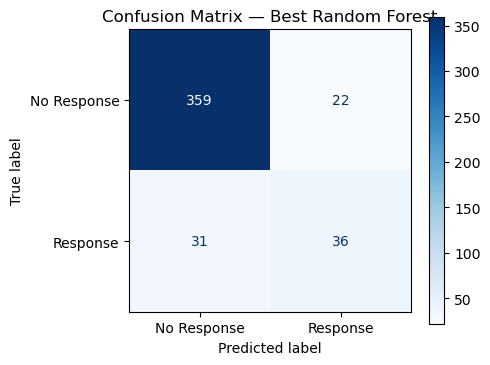

✔ Saved: confusion_matrix_rf.png


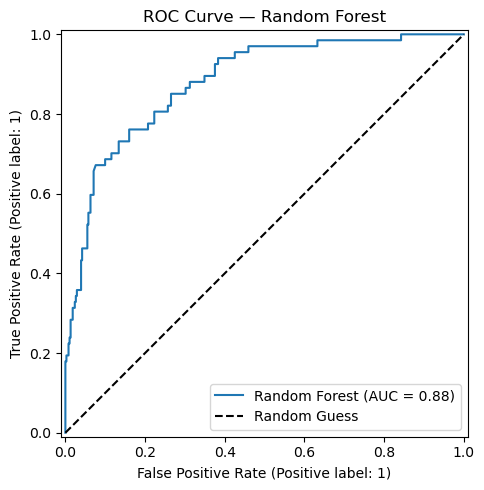

In [9]:
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

auc_rf   = roc_auc_score(y_test, y_prob_best)
prec_rf  = precision_score(y_test, y_pred_best)
rec_rf   = recall_score(y_test, y_pred_best)
f1_rf    = f1_score(y_test, y_pred_best)
acc_rf   = accuracy_score(y_test, y_pred_best)

print(f"ROC-AUC    : {auc_rf:.4f}   ")
print(f"Precision  : {prec_rf:.4f}")
print(f"Recall     : {rec_rf:.4f}   ")
print(f"F1-Score   : {f1_rf:.4f}")
print(f"Accuracy   : {acc_rf:.4f}  ")
print("\nFull classification report:")
print(classification_report(y_test, y_pred_best, target_names=['No Response', 'Response']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test, y_test,
    display_labels=['No Response', 'Response'],
    cmap='Blues', ax=ax
)
ax.set_title("Confusion Matrix — Best Random Forest")
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150)
plt.show()
print("✔ Saved: confusion_matrix_rf.png")

# ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax, name="Random Forest")
ax.plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax.set_title("ROC Curve — Random Forest")
ax.legend()
plt.tight_layout()
plt.show()


The tuned Random Forest achieves a **ROC-AUC** of approximately **0.88**, indicating strong ability to distinguish between customers who respond to the campaign and those who do not.

Looking at the classification metrics, the model achieves **precision** of **0.62** and **recall** of **0.54** for the responding class. This suggests that while the model identifies a meaningful portion of responders, some potential responders are still missed, which is expected given the class imbalance in the dataset.

The **confusion matrix** shows that the model correctly classifies most non-responding customers, while also identifying a substantial number of actual responders. Overall, the results indicate that the model provides a useful balance between identifying likely responders and avoiding excessive false positives.

The ROC curve further confirms strong discrimination performance, with the model clearly outperforming the random baseline.

### 3.5 Threshold Tuning

In marketing applications, it is often **more costly to miss a potential buyer (false negative)** than to contact a customer who ultimately does not purchase (false positive).

To explore this trade-off, we evaluate model performance under several probability thresholds. Lower thresholds increase recall by identifying a larger share of potential responders, while higher thresholds improve precision by reducing false positives.

 Threshold  Precision  Recall     F1  Positives predicted
       0.2     0.3073  0.8806 0.4556                  192
       0.3     0.4048  0.7612 0.5285                  126
       0.4     0.5000  0.7015 0.5839                   94
       0.5     0.6207  0.5373 0.5760                   58

→ For marketing campaigns we recommend threshold = 0.3:
  Higher Recall means fewer missed buyers (lower false negatives).


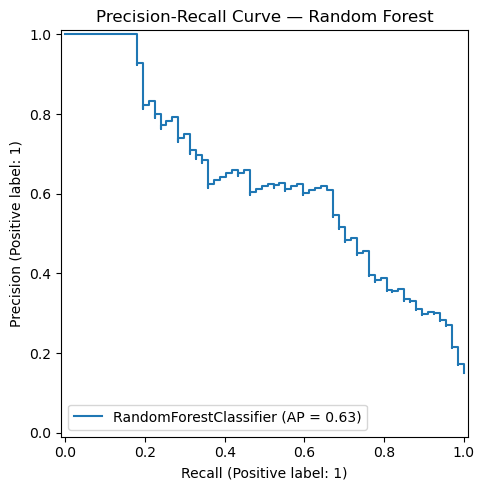

In [10]:
thresholds = [0.2, 0.3, 0.4, 0.5]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    threshold_results.append({
        'Threshold': t,
        'Precision': round(precision_score(y_test, y_pred_t), 4),
        'Recall':    round(recall_score(y_test, y_pred_t), 4),
        'F1':        round(f1_score(y_test, y_pred_t), 4),
        'Positives predicted': y_pred_t.sum()
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))
print("\n→ For marketing campaigns we recommend threshold = 0.3:")
print("  Higher Recall means fewer missed buyers (lower false negatives).")

# --- Precision-Recall Curve ---
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_estimator(best_rf, X_test, y_test, ax=ax)
ax.set_title("Precision-Recall Curve — Random Forest")
plt.tight_layout()
plt.show()

Based on the results, we select **0.3 as the operational threshold**. This setting captures a larger share of potential responders while maintaining a reasonable level of precision, which aligns with the campaign objective of minimising missed buyers.

### 3.6 Learning Curves

Learning curves show how model performance changes as the amount of training data increases. They allow us to assess whether the model is suffering from **overfitting or underfitting**, and whether additional training data could improve performance.

- If the training score is much higher than the validation score, the model may be **overfitting**.
- If both scores are low, the model may be **underfitting**.

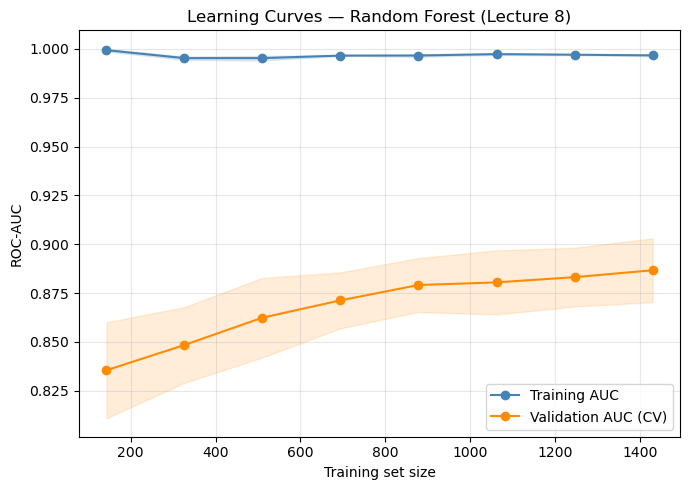

In [11]:
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train, y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training AUC')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation AUC (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='darkorange')
ax.set_xlabel("Training set size")
ax.set_ylabel("ROC-AUC")
ax.set_title("Learning Curves — Random Forest (Lecture 8)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The learning curves show that the **training AUC** remains very high, while the **validation AUC** gradually increases as more training data is used. The gap between the training and validation scores indicates that the model fits the training data extremely well, while its performance on unseen data is slightly lower.

However, the steady improvement in validation performance suggests that the **model continues to benefit from additional training data**. Overall, the model captures meaningful patterns in the data while still leaving some room for improvement in generalisation.

### 3.7 Feature importance

To understand which variables contribute most to the model’s predictions, we examine the feature importance scores produced by the Random Forest model. These scores measure the **mean decrease in impurity (Gini)**, indicating how much each feature helps reduce classification error across the trees in the forest.

Higher values indicate features that play a larger role in the model’s decision-making process.

Top 15 features by RF importance:
Total_Accepted_Campaigns    0.154346
Recency                     0.148510
Customer_Tenure             0.145065
Total_Spending              0.129696
Income                      0.105413
Total_Purchases             0.055003
NumWebVisitsMonth           0.054670
Age                         0.054134
NumDealsPurchases           0.034382
Teenhome                    0.031449
Education_PhD               0.014996
Marital_Status_Single       0.012788
Marital_Status_Married      0.012613
Marital_Status_Together     0.012105
Kidhome                     0.010951


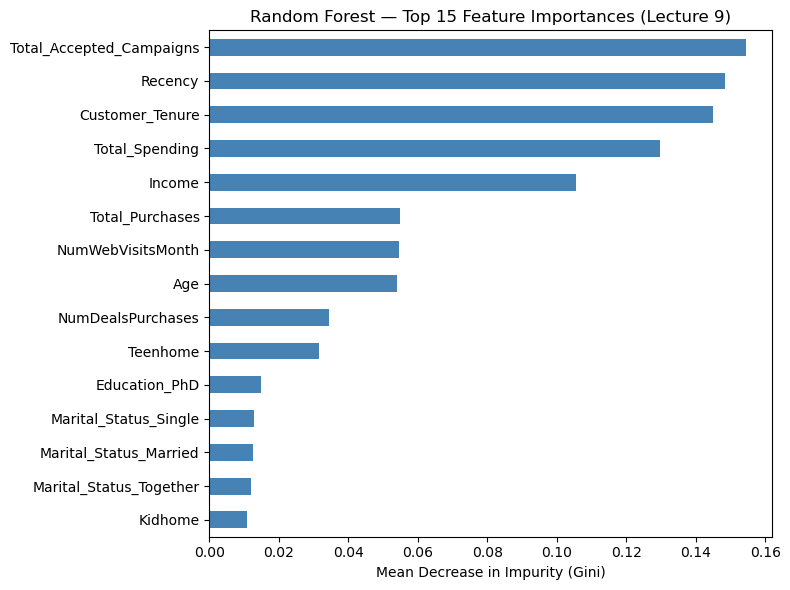

In [12]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 features by RF importance:")
print(importances.head(15).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel("Mean Decrease in Impurity (Gini)")
ax.set_title("Random Forest — Top 15 Feature Importances (Lecture 9)")
plt.tight_layout()
plt.show()

The feature importance results indicate that `Total_Accepted_Campaigns`, `Recency`, and `Customer_Tenure` are the most influential predictors of campaign response. These variables reflect prior engagement with marketing campaigns and the recency of customer activity, suggesting that customers who have interacted with campaigns before and have been active more recently are more likely to respond.

Spending and purchasing behaviour variables, including `Total_Spending`, `Income`, and `Total_Purchases`, also contribute meaningfully to the model’s predictions. In contrast, demographic features such as `Educatio`n and `Marital_Status` appear lower in the importance ranking within this model.

### 3.8 Permutation importance

To obtain a more robust measure of feature importance, we compute permutation importance on the test set. This method evaluates the contribution of each feature by randomly shuffling its values and measuring the resulting drop in model performance.

If shuffling a feature leads to a large decrease in ROC-AUC, it indicates that the feature plays an important role in the model’s predictions.

Top 15 features by Permutation Importance (on test set):
                 feature  importance_mean  importance_std
                 Recency         0.072907        0.010809
Total_Accepted_Campaigns         0.067325        0.013678
         Customer_Tenure         0.028151        0.008888
          Total_Spending         0.022803        0.009458
       NumWebVisitsMonth         0.011631        0.005247
                Teenhome         0.009269        0.007589
  Marital_Status_Married         0.004820        0.002715
                  Income         0.004117        0.003296
 Marital_Status_Together         0.003724        0.002467
   Marital_Status_Single         0.003201        0.001326
         Total_Purchases         0.001855        0.003896
         Education_Basic         0.001285        0.000278
                     Age         0.001148        0.002481
                 Kidhome         0.001089        0.001358
        Education_Master         0.000499        0.000731


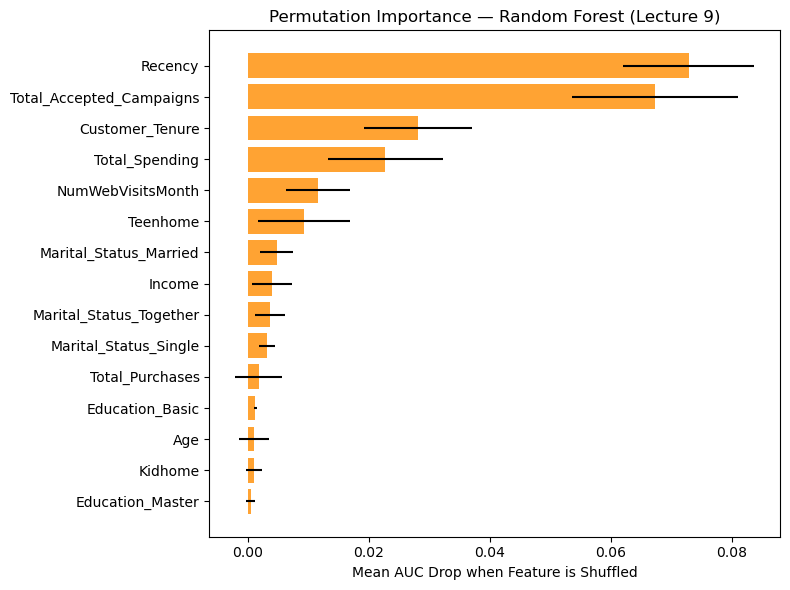

In [13]:
perm_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=1
)

perm_df = pd.DataFrame({
    'feature':          X_train.columns,
    'importance_mean':  perm_result.importances_mean,
    'importance_std':   perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print("Top 15 features by Permutation Importance (on test set):")
print(perm_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
top_perm = perm_df.head(15).sort_values('importance_mean')
ax.barh(top_perm['feature'], top_perm['importance_mean'],
        xerr=top_perm['importance_std'], color='darkorange', alpha=0.8)
ax.set_xlabel("Mean AUC Drop when Feature is Shuffled")
ax.set_title("Permutation Importance — Random Forest (Lecture 9)")
plt.tight_layout()
plt.show()

The permutation importance results show that `Recency` and `Total_Accepted_Campaigns` have the **largest impact on model performance**, as shuffling these variables produces the greatest drop in AUC. This suggests that recent customer activity and prior engagement with marketing campaigns are key signals for predicting response.

Other variables related to customer activity and engagement also contribute to the model’s predictions, although to a lesser extent.

### 3.9 SHAP values

To further interpret the model, we compute SHAP (SHapley Additive exPlanations) values. SHAP quantifies how each feature contributes to the model’s prediction by measuring how much it increases or decreases the predicted probability relative to a baseline.

SHAP values provide both **global explanations** (which features are most influential overall) and **local explanations** (how individual features influence a specific prediction).

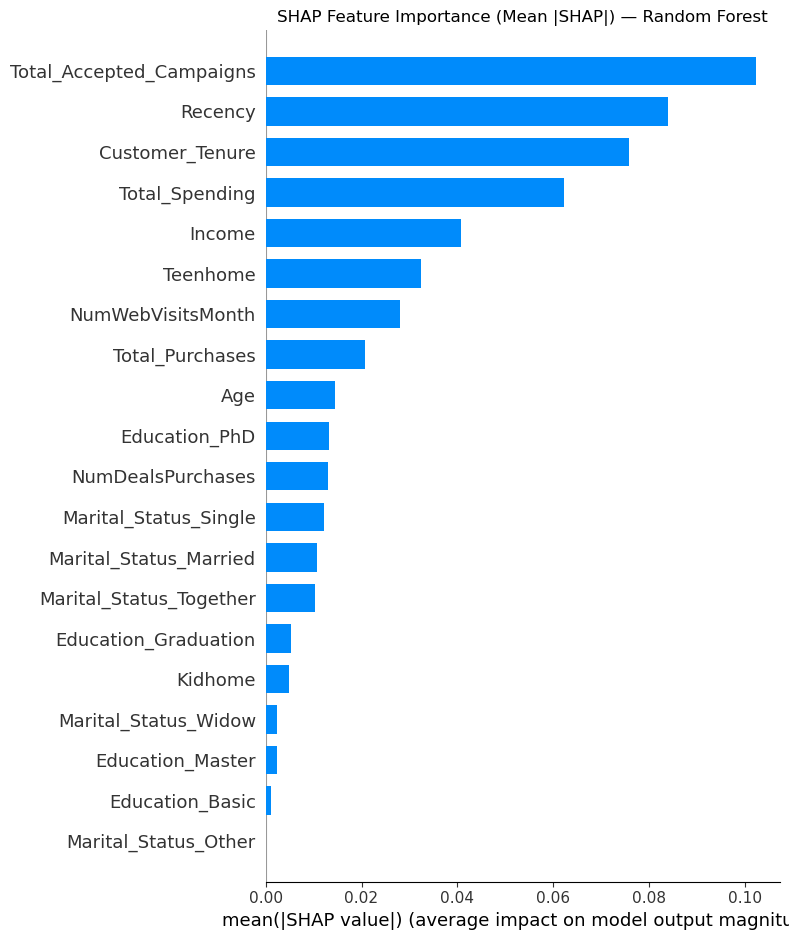

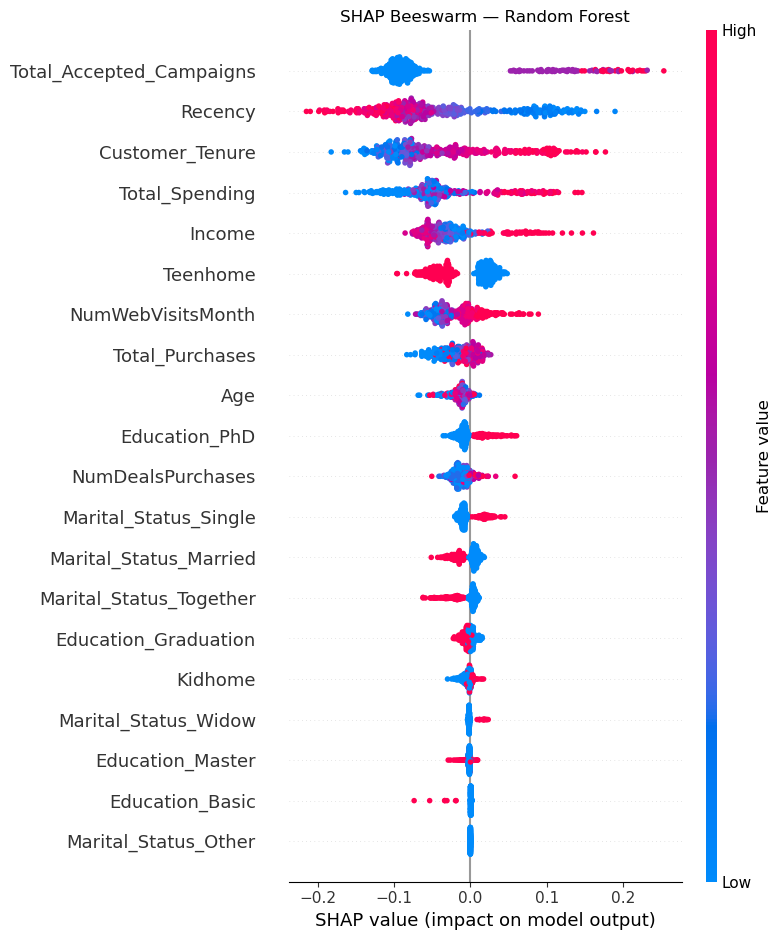

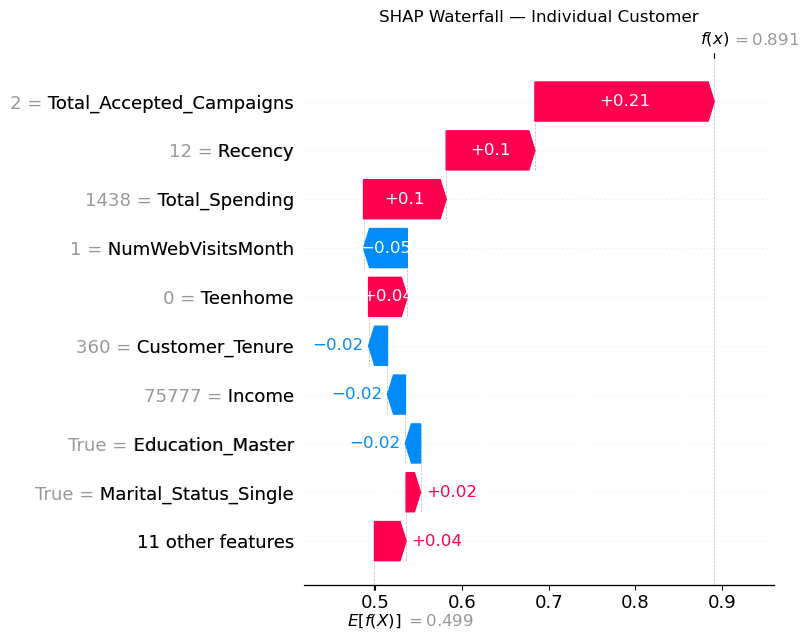

Customer predicted probability: 0.891


In [14]:
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# shap_values is a list [class_0_vals, class_1_vals] for binary RF
# Use index 1 for the positive class (Response = 1)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

# Global summary: bar chart (average absolute SHAP)
shap.summary_plot(sv, X_test, plot_type='bar', show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|) — Random Forest")
plt.tight_layout()
plt.show()

# Global beeswarm: shows direction + magnitude of each feature
shap.summary_plot(sv, X_test, show=False)
plt.title("SHAP Beeswarm — Random Forest")
plt.tight_layout()
plt.show()

# Local explanation: explain one individual prediction
top_idx  = np.argmax(y_prob_best)
single_x = X_test.iloc[[top_idx]]

sv_raw = explainer.shap_values(single_x)

# SHAP >= 0.45 returns a 3D array (n_samples, n_features, n_classes)
# SHAP <  0.45 returns a list [class_0_array, class_1_array]
if isinstance(sv_raw, list):
    sv_single    = sv_raw[1][0]           # old API
    base_value   = explainer.expected_value[1]
else:
    sv_single    = sv_raw[0, :, 1]        # new API
    base_value   = explainer.expected_value[1]

shap.waterfall_plot(
    shap.Explanation(
        values        = sv_single,
        base_values   = base_value,
        data          = single_x.values[0],
        feature_names = X_test.columns.tolist()
    ),
    show=False
)
plt.title("SHAP Waterfall — Individual Customer")
plt.tight_layout()
plt.show()
print(f"Customer predicted probability: {y_prob_best[top_idx]:.3f}")

The SHAP analysis provides a detailed view of how different features influence the model’s predictions. Consistent with the previous feature importance analyses, variables related to **customer engagement and recent activity show the strongest impact on predicted campaign response**. In particular, **past campaign acceptance, recency of interaction, and customer tenure** appear among the **most influential** factors driving the model’s predictions.

The distribution of SHAP values also illustrates how different feature values affect the prediction. Higher levels of engagement or spending tend to push predictions toward a higher probability of response, while lower activity levels generally decrease the predicted likelihood of responding.

Finally, the individual SHAP explanation highlights how multiple features combine to influence a single prediction. In the example shown, factors such as **prior campaign acceptance, recent activity, and spending behaviour** contribute **positively** to the **predicted response probability** for the selected customer.

## 4. Behavioural and Demographic Models - Random Forest

The full model analysis in Section 3 established the best-performing Random Forest configuration. In this section, we apply the same hyperparameters to the behavioural and demographic feature sets to evaluate **which type of information contributes more to predicting campaign respons**. 

We report the core metrics only, detailed SHAP/explainability is reserved for the best-performing model in the comparison table.

### 4.1 Behavioural Model

ROC-AUC   : 0.8553
Precision : 0.4921
Recall    : 0.4627
F1-Score  : 0.4769


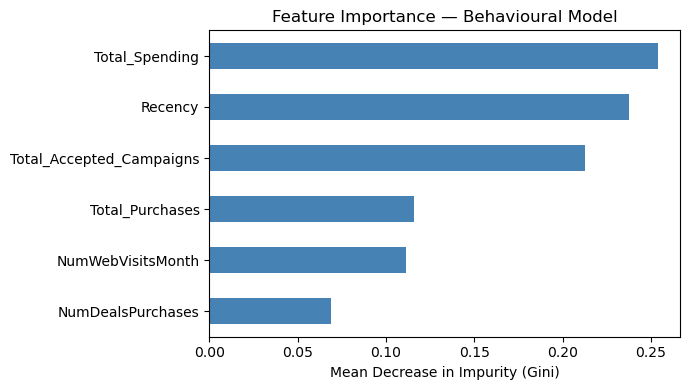

In [21]:
# Reuse best params from RandomizedSearchCV
best_params = random_search.best_params_

rf_behav = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_behav.fit(X_behav_train, y_train)

y_prob_behav = rf_behav.predict_proba(X_behav_test)[:, 1]
y_pred_behav = rf_behav.predict(X_behav_test)

print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_behav):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_behav):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_behav):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_behav):.4f}")

# Feature importance — behavioural model
imp_behav = pd.Series(
    rf_behav.feature_importances_,
    index=X_behav_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
imp_behav.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Feature Importance — Behavioural Model")
ax.set_xlabel("Mean Decrease in Impurity (Gini)")
plt.tight_layout()
plt.show()

The behavioural model achieves a **ROC-AUC** of approximately **0.86**, indicating that **behavioural variables** alone provide **strong predictive power** for campaign response. Although performance is slightly lower than the full model, the results suggest that customer behaviour and engagement indicators capture a substantial share of the information needed for prediction.

The feature importance plot highlights that `Total_Spending`, `Recency`, and `Total_Accepted_Campaigns` are among the most influential predictors in this model. These variables reflect purchasing activity and prior interaction with marketing campaigns, reinforcing the importance of behavioural signals when modelling customer response.

### 4.2 Demographic Model

ROC-AUC   : 0.7889
Precision : 0.4103
Recall    : 0.4776
F1-Score  : 0.4414


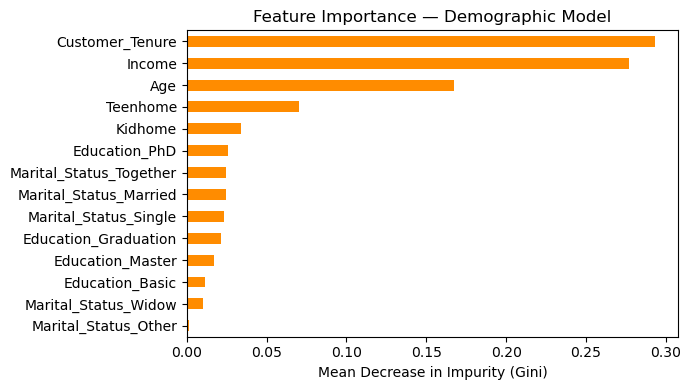

In [18]:
rf_demo = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_demo.fit(X_demo_train, y_train)

y_prob_demo = rf_demo.predict_proba(X_demo_test)[:, 1]
y_pred_demo = rf_demo.predict(X_demo_test)

print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_demo):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_demo):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_demo):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_demo):.4f}")

# Feature importance — demographic model
imp_demo = pd.Series(
    rf_demo.feature_importances_,
    index=X_demo_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
imp_demo.sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_title("Feature Importance — Demographic Model")
ax.set_xlabel("Mean Decrease in Impurity (Gini)")
plt.tight_layout()
plt.show()

The demographic model achieves a **ROC-AUC** of approximately **0.79**, which is notably lower than the performance obtained using behavioural variables. This indicates that **demographic information** alone provides more **limited predictive power** for campaign response.

The feature importance results show that variables such as Customer_Tenure, Income, and Age contribute most within the demographic feature set. However, even the most influential demographic variables have less predictive strength compared with the behavioural signals observed in the previous model.

### 4.3 Random Forest Model Comparison

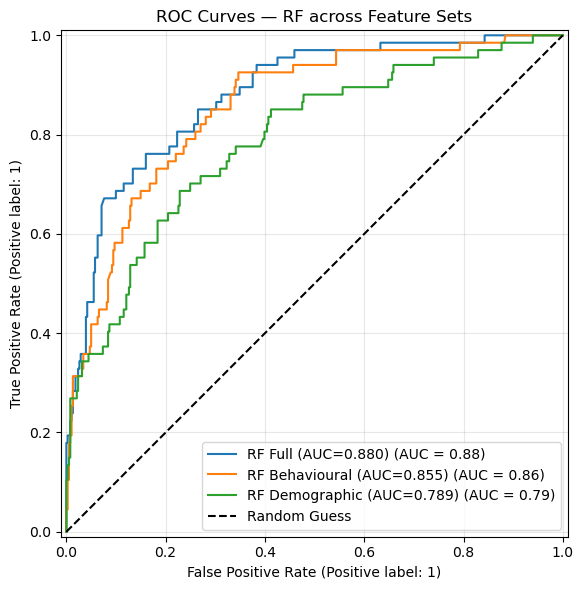

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test, y_prob_best,
    ax=ax, name=f"RF Full (AUC={roc_auc_score(y_test, y_prob_best):.3f})"
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_behav,
    ax=ax, name=f"RF Behavioural (AUC={roc_auc_score(y_test, y_prob_behav):.3f})"
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_demo,
    ax=ax, name=f"RF Demographic (AUC={roc_auc_score(y_test, y_prob_demo):.3f})"
)
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title("ROC Curves — RF across Feature Sets")
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The ROC curves clearly show that the **full Random Forest model** achieves the **best overall performance (AUC ≈ 0.88)**. The behavioural model performs slightly worse (AUC ≈ 0.86) but still retains most of the predictive power of the full model. In contrast, the demographic model shows noticeably lower performance (AUC ≈ 0.79).

These results indicate that behavioural variables capture the majority of the predictive signal for campaign response, while demographic characteristics alone provide more limited information. Nevertheless, combining both types of features in the full model yields the strongest overall performance.

## 5. Full Model - XGBoost

XGBoost is the dominant implementation. Adding it creates a 3-model comparison (LR vs RF vs XGB), which significantly strengthens the results.

In [15]:
# scale_pos_weight handles class imbalance in XGBoost:
# set to ratio of negative/positive samples
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale     = neg_count / pos_count
print(f"scale_pos_weight = {scale:.2f}  (neg/pos ratio for class balance)")

xgb = XGBClassifier(
    n_estimators     = 5,
    max_depth        = 5,
    learning_rate    = 0.05,
    scale_pos_weight = scale,
    random_state     = 42,
    eval_metric      = 'auc',
    use_label_encoder= False,
    n_jobs           = 1,
    verbosity        = 0
    )
xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb.predict(X_test)

print(f"XGBoost — ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"XGBoost — Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"XGBoost — F1       : {f1_score(y_test, y_pred_xgb):.4f}")

scale_pos_weight = 5.70  (neg/pos ratio for class balance)
XGBoost — ROC-AUC  : 0.8325
XGBoost — Recall   : 0.6567
XGBoost — F1       : 0.4916


## 6. Behavioural and Demographic Models - XGBoost

### 6.1 Behavioural Model

In [24]:
print("Features:", numerical_features_behav)

xgb_behav = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    scale_pos_weight=neg_count / pos_count,
    random_state=42, eval_metric='auc',
    use_label_encoder=False, n_jobs=-1, verbosity=0
)
xgb_behav.fit(X_behav_train, y_train)

y_prob_xgb_behav = xgb_behav.predict_proba(X_behav_test)[:, 1]
y_pred_xgb_behav = xgb_behav.predict(X_behav_test)

print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_xgb_behav):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb_behav):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb_behav):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_xgb_behav):.4f}")

Features: ['Recency', 'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns', 'NumDealsPurchases', 'NumWebVisitsMonth']
ROC-AUC   : 0.8404
Precision : 0.4545
Recall    : 0.5970
F1-Score  : 0.5161


### 6.2 Demographic Model

In [25]:
print("Features:", numerical_features_demo, categorical_features_demo)

xgb_demo = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    scale_pos_weight=neg_count / pos_count,
    random_state=42, eval_metric='auc',
    use_label_encoder=False, n_jobs=-1, verbosity=0
)
xgb_demo.fit(X_demo_train, y_train)

y_prob_xgb_demo = xgb_demo.predict_proba(X_demo_test)[:, 1]
y_pred_xgb_demo = xgb_demo.predict(X_demo_test)

print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_xgb_demo):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb_demo):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb_demo):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_xgb_demo):.4f}")

Features: ['Age', 'Income', 'Customer_Tenure', 'Kidhome', 'Teenhome'] ['Education', 'Marital_Status']
ROC-AUC   : 0.7590
Precision : 0.3626
Recall    : 0.4925
F1-Score  : 0.4177


## 7. Model Comparison

MODEL COMPARISON TABLE
                   ROC-AUC  Precision  Recall  F1-Score  Accuracy
Model                                                            
LR  — Behavioural   0.8590     0.3858  0.7313    0.5052    0.7857
LR  — Demographic   0.7663     0.2848  0.7015    0.4052    0.6920
LR  — Full          0.8795     0.4113  0.7612    0.5340    0.8013
RF  — Behavioural   0.8553     0.4921  0.4627    0.4769    0.8482
RF  — Demographic   0.7889     0.4103  0.4776    0.4414    0.8192
RF  — Full          0.8799     0.6207  0.5373    0.5760    0.8817
XGB — Behavioural   0.8404     0.4545  0.5970    0.5161    0.8326
XGB — Demographic   0.7590     0.3626  0.4925    0.4177    0.7946
XGB — Full          0.8840     0.5185  0.6269    0.5676    0.8571

=== Algorithm Comparison (Full feature set) ===
            ROC-AUC  Precision  Recall  F1-Score  Accuracy
Model                                                     
LR  — Full   0.8795     0.4113  0.7612    0.5340    0.8013
RF  — Full   0.8799     0

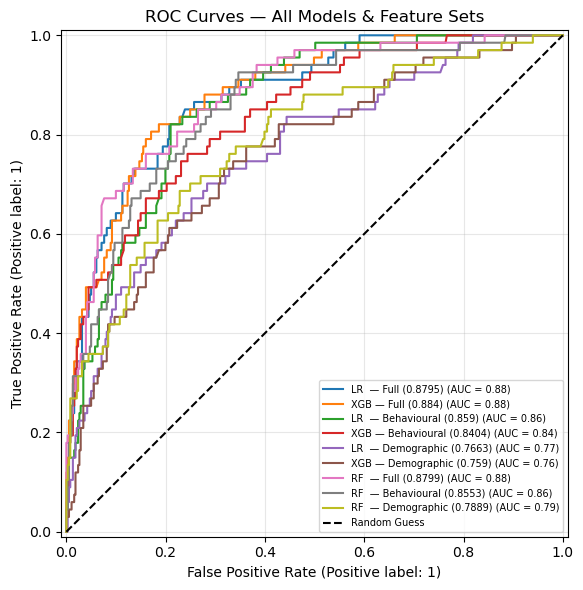

In [20]:
def evaluate_model(model, X_te, y_te, model_name):
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)
    return {
        'Model':     model_name,
        'ROC-AUC':   round(roc_auc_score(y_te, y_prob), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred), 4),
        'F1-Score':  round(f1_score(y_te, y_pred), 4),
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        '_prob':     y_prob
    }

results = []

feature_sets = [
    ('Full',        X_full_train,  X_full_test),
    ('Behavioural', X_behav_train, X_behav_test),
    ('Demographic', X_demo_train,  X_demo_test),
]

# Logistic Regression: fit for each feature set
for fs_name, X_tr, X_te in feature_sets:

    # Logistic Regression
    lr_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=42
        ))
    ])
    lr_pipe.fit(X_tr, y_train)
    results.append(evaluate_model(lr_pipe, X_te, y_test, f"LR  — {fs_name}"))

# XGBoost
results.append(evaluate_model(xgb,       X_full_test,  y_test, "XGB — Full"))
results.append(evaluate_model(xgb_behav, X_behav_test, y_test, "XGB — Behavioural"))
results.append(evaluate_model(xgb_demo,  X_demo_test,  y_test, "XGB — Demographic"))

# Random Forest
results.append(evaluate_model(best_rf,  X_full_test,  y_test, "RF  — Full"))
results.append(evaluate_model(rf_behav, X_behav_test, y_test, "RF  — Behavioural"))
results.append(evaluate_model(rf_demo,  X_demo_test,  y_test, "RF  — Demographic"))

# Build and display comparison table
comparison_df = (
    pd.DataFrame(results)
    .drop(columns='_prob')
    .set_index('Model')
    .sort_index()
)

print("MODEL COMPARISON TABLE")
print(comparison_df.to_string())

# Reading 1: algorithm comparison within each feature set
print("\n=== Algorithm Comparison (Full feature set) ===")
print(comparison_df.filter(like='Full', axis=0).to_string())

print("\n=== Algorithm Comparison (Behavioural feature set) ===")
print(comparison_df.filter(like='Behavioural', axis=0).to_string())

print("\n=== Algorithm Comparison (Demographic feature set) ===")
print(comparison_df.filter(like='Demographic', axis=0).to_string())

# Reading 2: feature set comparison within each algorithm
print("\n=== Feature Set Comparison (LR only) ===")
print(comparison_df.filter(like='LR', axis=0).to_string())

print("\n=== Feature Set Comparison (RF only) ===")
print(comparison_df.filter(like='RF', axis=0).to_string())

print("\n=== Feature Set Comparison (XGB only) ===")
print(comparison_df.filter(like='XGB', axis=0).to_string())

# Best model overall
best_model_name = comparison_df['ROC-AUC'].idxmax()
print(f"\nBest model by ROC-AUC : {best_model_name}")
print(f"AUC                   : {comparison_df.loc[best_model_name, 'ROC-AUC']}")

# Overlapping ROC curves: all models
fig, ax = plt.subplots(figsize=(8, 6))
for entry in results:
    RocCurveDisplay.from_predictions(
        y_test, entry['_prob'],
        ax=ax, name=f"{entry['Model']} ({entry['ROC-AUC']})"
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax.set_title("ROC Curves — All Models & Feature Sets")
ax.legend(loc='lower right', fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary of Results